In [128]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt 


### <center> Solutions to the example_SIR Notebook Exercises 

Evaluate the effect of changing `delta_t` on the solution. In particular, choose different values of `delta_t` and graph the resultant $I(t)$ curve for each `delta_t` on the same plot. 

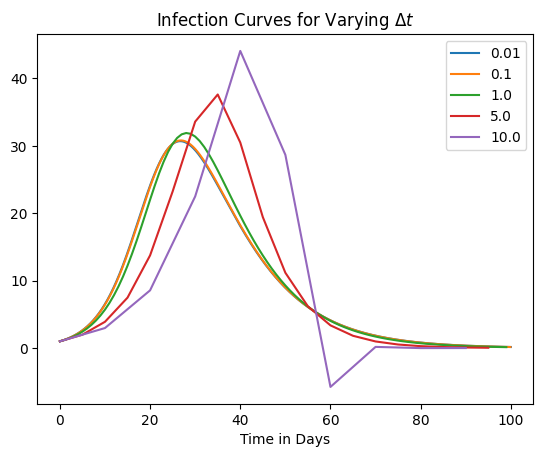

In [129]:
def EulerStepper(x_prev,delta_t=0.01,*, par = None, func):
        x_next = x_prev + delta_t * func(x_prev,par)
        return x_next

par = jnp.array([0.3,0.1]) #beta,gamma
X0 = jnp.array([100.0,1.0,0.0]) #S_0,I_0,R_0

 
def SIR_func(X,par): 
    beta,gamma = par #Unpack parameter tuple

    S,I,R = X #Unpack input array 

    N = S+I+R #Total population

    ## Derivatives ##
    dS = -beta/N * S * I
    dI = beta/N * S * I - gamma * I
    dR = gamma * I

    return jnp.array([dS,dI,dR])

def solver(delta_t,X0,par,func,steps):

    beta,gamma = par

    X = jnp.zeros((steps,X0.shape[0])) #Array to hold solution values
    X = X.at[0,:].set(X0) #JAX arrays must be set this way, numpy syntax will not work.

    ## Euler solution loop ##
    for step in range(1,steps): 
        X_next = EulerStepper(X[step-1,:],delta_t = delta_t, par = (beta,gamma), func = func)
        X = X.at[step,:].set(X_next)

    return X

delta_ts = [0.01,0.1,1.0,5.0,10.0]

days = 100
for delta_t in delta_ts: 
    t_range = jnp.arange(0,days,delta_t)
    X_euler = solver(delta_t,X0,par,SIR_func,len(t_range))
    plt.plot(t_range,X_euler[:,1],label = delta_t)

plt.title('Infection Curves for Varying $\\Delta t$')
plt.xlabel('Time in Days')
plt.legend()
plt.show()


Evaluate the effect of changing $\beta$ and $\gamma$. Plot the results of keeping `gamma` fixed and changing `beta` and the results of keeping `beta` fixed and changing `gamma`. What happens if $\gamma > \beta$?

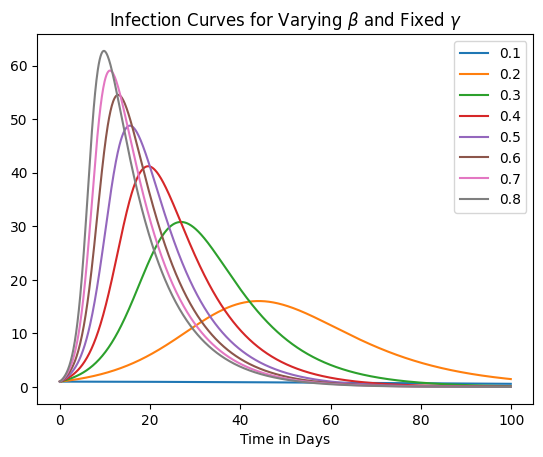

In [130]:
delta_t = 0.1
gamma = 0.1
betas = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]

days = 100
for beta in betas: 
    t_range = jnp.arange(0,days,delta_t)
    X_euler = solver(delta_t,X0,(beta,0.1),SIR_func,len(t_range))
    plt.plot(t_range,X_euler[:,1],label = beta)

plt.title('Infection Curves for Varying $\\beta$ and Fixed $\\gamma$')
plt.xlabel('Time in Days')
plt.legend()
plt.show()

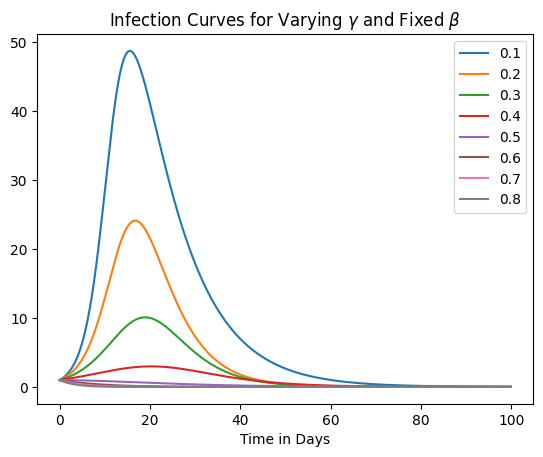

In [131]:
delta_t = 0.1
gammas = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
beta = 0.5

days = 100
for gamma in gammas: 
    t_range = jnp.arange(0,days,delta_t)
    X_euler = solver(delta_t,X0,(beta,gamma),SIR_func,len(t_range))
    plt.plot(t_range,X_euler[:,1],label = gamma)

plt.title('Infection Curves for Varying $\\gamma$ and Fixed $\\beta$')
plt.xlabel('Time in Days')
plt.legend()
plt.show()

If $\gamma > \beta$ no epidemic will occur. The number of infected will trail off towards zero exponentially. 

Try other likelihood functions than Poisson. In particular, try Gaussian and Negative Binomial distributions and see how the geometry of the likelihood surface changes. Keep in mind that the Gaussian distribution has an another parameter $\sigma$, the standard deviation. Similarly, the Negative Binomial distribution has an addition parameter $r$, the so called overdispersion when parameterized in terms of its mean. 

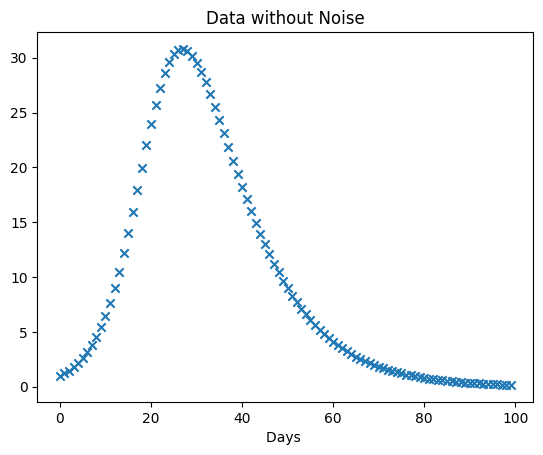

In [132]:
delta_t = 0.1
gamma = 0.1
beta = 0.3

days = 100

t_range = jnp.arange(0,days,delta_t)

X_euler = solver(delta_t,X0,(beta,gamma),SIR_func,len(t_range))
I = X_euler[:,1]
day_interval = int(1/delta_t)

data = I[::day_interval] ## Extracts every day_interval element from I

day_range = jnp.arange(0.,len(t_range)//day_interval,1.)

plt.title('Data without Noise')
plt.scatter(day_range,data,marker = 'x')
plt.xlabel('Days ')
plt.show()

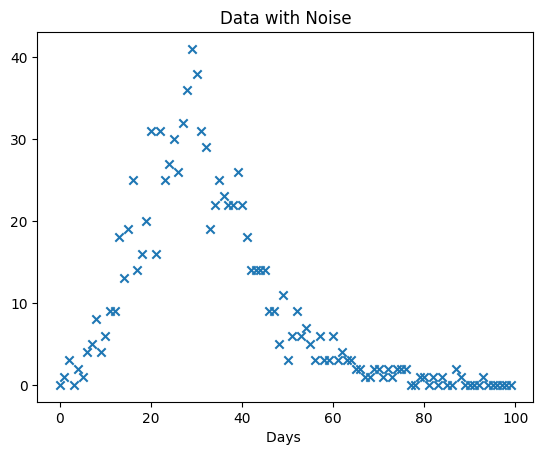

In [133]:
rng_key = jax.random.key(0)

rng_key,noise_key = jax.random.split(rng_key)

data = jax.random.poisson(noise_key,data)

del noise_key

plt.title('Data with Noise')
plt.scatter(day_range,data,marker = 'x')
plt.xlabel('Days ')
plt.show()

In [134]:
##First lets define our log-likelihood function 

@jax.jit
def log_likelihood_gaussian(theta,sigma): 
    t_range = jnp.arange(0,100,delta_t)
    day_interval = int(1/delta_t)
    X = solver(delta_t = delta_t,par = theta,X0 = X0, func = SIR_func,steps = len(t_range)) #Solve the system with the given theta
    I = X[::day_interval,1]
    I = jnp.clip(I, 1e-8, None) #Clip just in case I dips below zero

    return jnp.sum(jax.scipy.stats.norm.logpdf(x = data, loc = I,scale = sigma))

@jax.jit
def log_likelihood_poisson(theta): 
    t_range = jnp.arange(0,100,delta_t)
    day_interval = int(1/delta_t)
    X = solver(delta_t = delta_t,par = theta,X0 = X0, func = SIR_func,steps = len(t_range)) #Solve the system with the given theta
    I = X[::day_interval,1]
    I = jnp.clip(I, 1e-8, None) #Clip just in case I dips below zero

    return jnp.sum(jax.scipy.stats.poisson.logpmf(k = data, mu = I))

@jax.jit
def log_likelihood_NB(theta,r): 
    t_range = jnp.arange(0,100,delta_t)
    day_interval = int(1/delta_t)
    X = solver(delta_t = delta_t,par = theta,X0 = X0, func = SIR_func,steps = len(t_range)) #Solve the system with the given theta
    I = X[::day_interval,1]
    I = jnp.clip(I, 1e-8, None) #Clip just in case I dips below zero

    return jnp.sum(jax.scipy.stats.nbinom.logpmf(k = data, n = r, p = r/(I + r)))

In [135]:
sigma = 100.0
r = 1.0
betas = jnp.arange(0, 0.5, 0.01)  # Grid for betas
gammas = jnp.arange(0, 0.5, 0.01)  # Grid for gammas
X, Y = jnp.meshgrid(betas, gammas)
theta = jnp.concatenate((X[...,jnp.newaxis],Y[...,jnp.newaxis]),axis = -1)

vmap_LL_gaussian = jax.vmap(jax.vmap(lambda theta: log_likelihood_gaussian(theta,sigma)))
vmap_LL_nbinom = jax.vmap(jax.vmap(lambda theta: log_likelihood_NB(theta,r)))
vmap_LL_poisson = jax.vmap(jax.vmap(log_likelihood_poisson))
LL_gaussian= vmap_LL_gaussian(theta)
LL_poisson = vmap_LL_poisson(theta)
LL_nbinom = vmap_LL_nbinom(theta)

beta* = 0.29999998
gamma* = 0.099999994
max log-likelihood = -553.4585


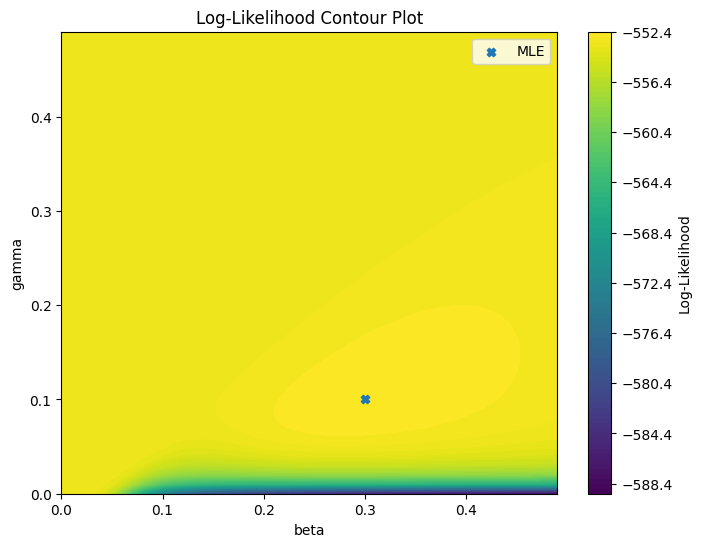

In [136]:
## Find the argmaximum in the grid
idx = jnp.argmax(LL_gaussian)
i, j = jnp.unravel_index(idx, LL_gaussian.shape)

beta_star  = betas[j]
gamma_star = gammas[i]
max_LL = LL_gaussian[j,i]

print("beta* =", beta_star)
print("gamma* =", gamma_star)
print("max log-likelihood =", max_LL)

## Plotting the log-likelihood as the heatmap

plt.figure(figsize=(8,6))
cp = plt.contourf(X, Y, LL_gaussian, levels=100,cmap = 'viridis')
plt.colorbar(cp, label='Log-Likelihood')
plt.scatter(beta_star,gamma_star,marker = 'X',label = 'MLE')

plt.xlabel("beta")
plt.ylabel("gamma")
plt.title("Log-Likelihood Contour Plot")
plt.legend()

plt.show()

beta* = 0.31
gamma* = 0.099999994
max log-likelihood = -8432.166


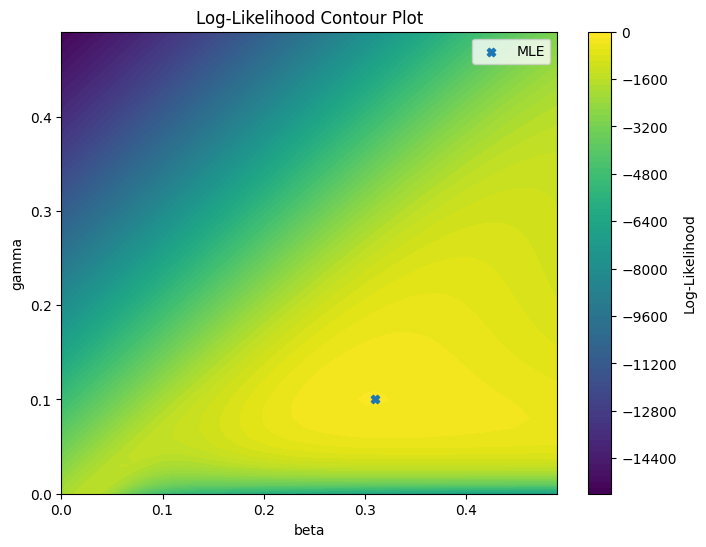

In [137]:
## Find the argmaximum in the grid
idx = jnp.argmax(LL_poisson)
i, j = jnp.unravel_index(idx, LL_poisson.shape)

beta_star  = betas[j]
gamma_star = gammas[i]
max_LL = LL_poisson[j,i]

print("beta* =", beta_star)
print("gamma* =", gamma_star)
print("max log-likelihood =", max_LL)

plt.figure(figsize=(8,6))
cp = plt.contourf(X, Y, LL_poisson, levels=100,cmap = 'viridis')
plt.colorbar(cp, label='Log-Likelihood')
plt.scatter(beta_star,gamma_star,marker = 'X',label = 'MLE')

plt.xlabel("beta")
plt.ylabel("gamma")
plt.title("Log-Likelihood Contour Plot")
plt.legend()

plt.show()

beta* = 0.31
gamma* = 0.099999994
max log-likelihood = -inf


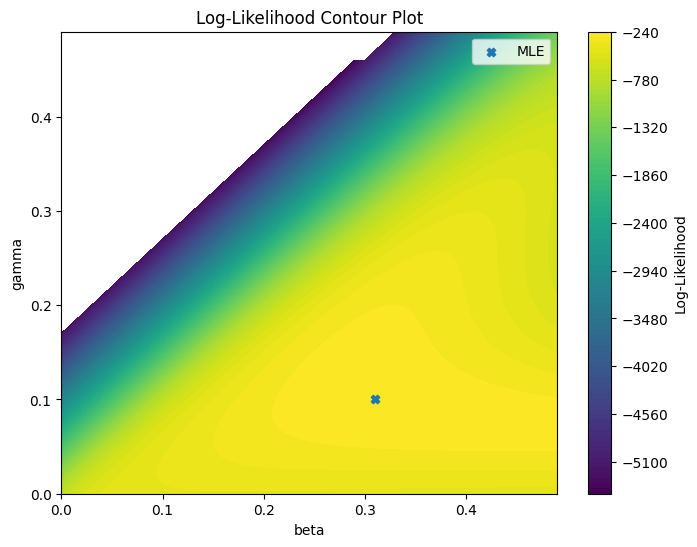

In [138]:
## Find the argmaximum in the grid
idx = jnp.argmax(LL_nbinom)
i, j = jnp.unravel_index(idx, LL_nbinom.shape)

beta_star  = betas[j]
gamma_star = gammas[i]
max_LL = LL_nbinom[j,i]

print("beta* =", beta_star)
print("gamma* =", gamma_star)
print("max log-likelihood =", max_LL)

plt.figure(figsize=(8,6))
cp = plt.contourf(X, Y, LL_nbinom, levels=100,cmap = 'viridis')
plt.colorbar(cp, label='Log-Likelihood')
plt.scatter(beta_star,gamma_star,marker = 'X',label = 'MLE')

plt.xlabel("beta")
plt.ylabel("gamma")
plt.title("Log-Likelihood Contour Plot")
plt.legend()

plt.show()

Changing the $\sigma$ parameter and $r$ parameter in the negative binomial and gaussian likelihoods generally preserves the qualitative features of the geometry while changing their magnitude. 

Change the amount of data and examine how the likelihood function changes, maintaining the Poisson assumption. For example, change the data resolution to weekly or decrease the number of days of data collection.  

In [139]:

def log_likelihood_poisson(theta, days): 
    t_range = jnp.arange(0, days, delta_t)
    day_interval = int(1/delta_t)
    
    X_sol = solver(delta_t=delta_t, par=theta, X0=X0, func=SIR_func, steps=len(t_range))
    
    I = X_sol[::day_interval, 1]
    I = jnp.clip(I, 1e-8, None) 

    current_data = data[:I.shape[0]] 

    return jnp.sum(jax.scipy.stats.poisson.logpmf(k=current_data, mu=I))

betas = jnp.arange(0, 0.5, 0.01)  # Grid for betas
gammas = jnp.arange(0, 0.5, 0.01)  # Grid for gammas
X, Y = jnp.meshgrid(betas, gammas)
theta = jnp.concatenate((X[...,jnp.newaxis],Y[...,jnp.newaxis]),axis = -1)

vmap_LL_poisson = jax.vmap(jax.vmap(log_likelihood_poisson,in_axes = (0,None)),in_axes = (0,None))


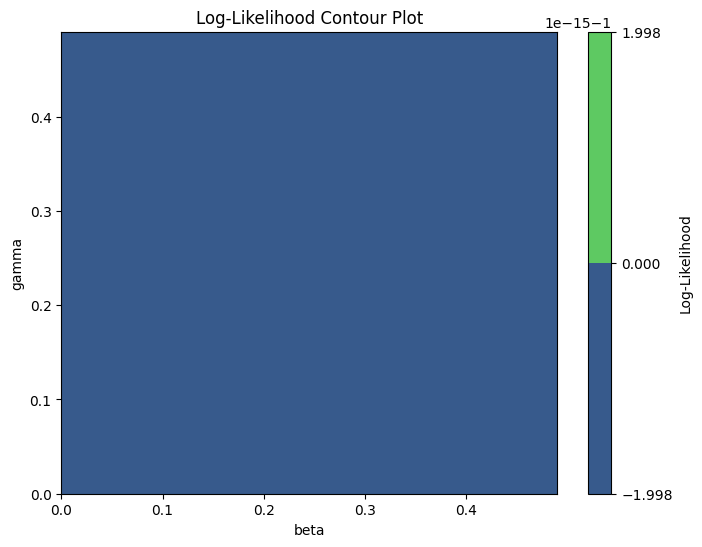

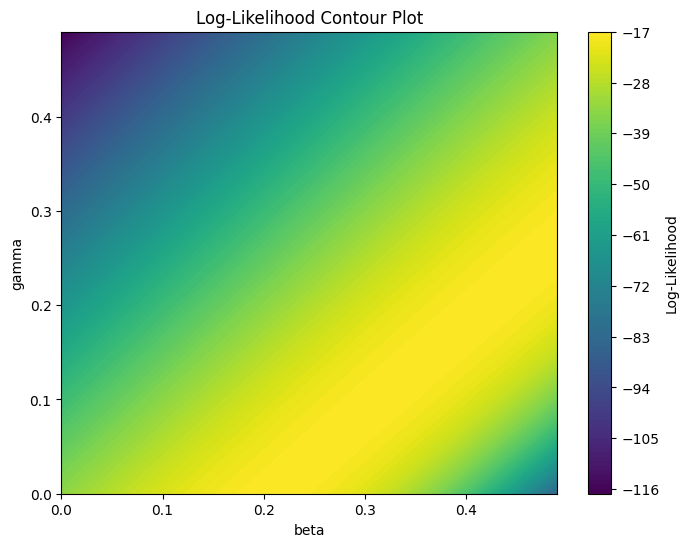

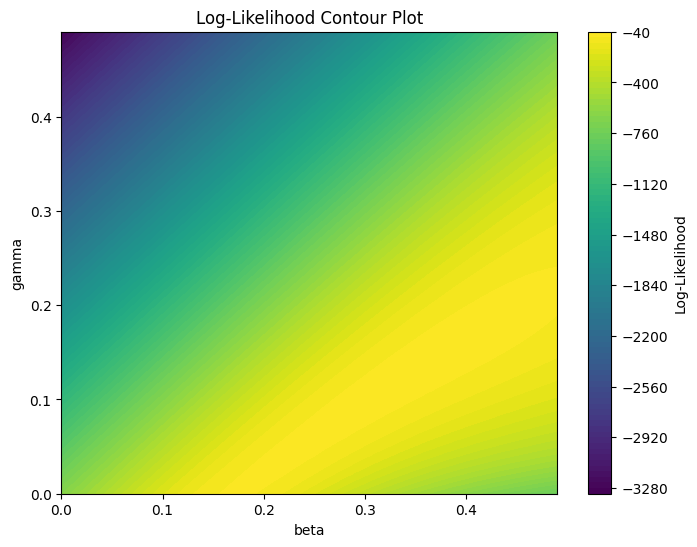

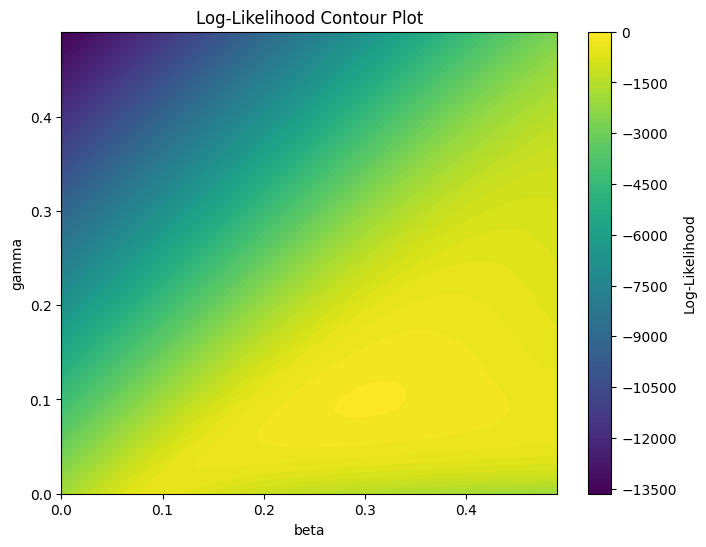

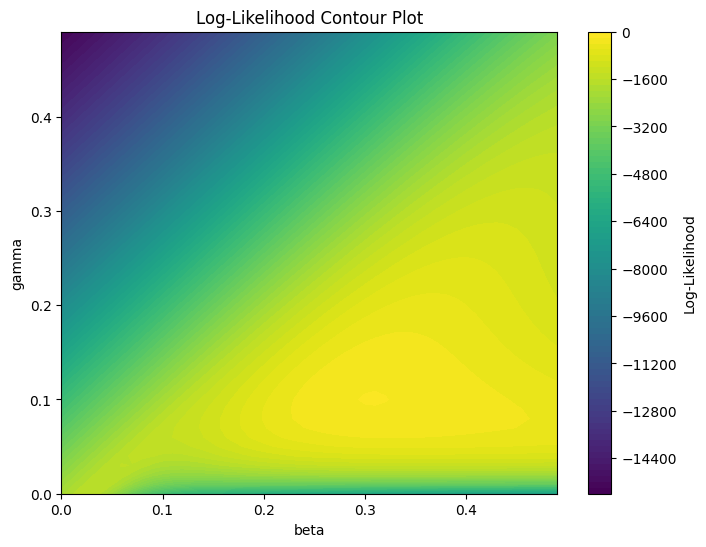

In [140]:
day_list = [1,10,25,50,100]

for day in day_list: 
    plt.figure(figsize=(8,6))
    cp = plt.contourf(X, Y, vmap_LL_poisson(theta,day), levels=100,cmap = 'viridis')
    plt.colorbar(cp, label='Log-Likelihood')

    plt.title(f'Likelihood for {day} days')
    plt.xlabel("beta")
    plt.ylabel("gamma")
    plt.title("Log-Likelihood Contour Plot")

    plt.show()

We see the development of a well-defined global maximum as the number of days of data increases. This suggests that for satisfactory inference there is some minimum amount of data necessary. 

Implement gradient ascent to find the maximum of the log_likelihood function. This will be 4-5 lines of code inside a loop. 

In [141]:
from diffrax import diffeqsolve, Dopri5, ODETerm, SaveAt

def diffrax_solver(delta_t,X0,par,func,steps):

    term = ODETerm(lambda t,X,par: func(X,par))
    solver = Dopri5()
    times = jnp.arange(0,int(steps * delta_t),1.)
    saveat = SaveAt(ts = times)

    sol = diffeqsolve(terms = term,solver = solver,t0 = times[0],t1 = times[-1],dt0 = delta_t,y0 = X0, args = par,saveat = saveat)
    
    return sol.ys 

steps = 1000

### Using our updated solver
X_new = diffrax_solver(delta_t,X0,par,SIR_func,steps)

##Now lets redefine our likelihood function with the new solver. 
def log_likelihood(theta): 
    delta_t = 0.1
    X = diffrax_solver(delta_t = delta_t,par = jnp.exp(theta),X0 = X0, func = SIR_func,steps = steps) #Solve the system with the given theta
    I = X[:,1] #We don't need the sampling step anymore. We told diffrax to save only at daily intervals.
    I = jnp.clip(I, 1e-8, None) #Clip just in case I dips below zero

    return jnp.sum(jax.scipy.stats.poisson.logpmf(k = data, mu = I))



In [142]:
step_size = 0.0001
iterations = 20
theta = jnp.log(jnp.array([0.1,0.1]))
grad_LL = jax.value_and_grad(log_likelihood)

for i in range(iterations): 
    value,grad = grad_LL(theta)
    print(f"Log_likelihood at iteration: {i} is {value} with theta {jnp.exp(theta)}")
    theta = theta + step_size * grad

Log_likelihood at iteration: 0 is -2130.505859375 with theta [0.1 0.1]
Log_likelihood at iteration: 1 is -1285.9501953125 with theta [0.12824051 0.07711859]
Log_likelihood at iteration: 2 is -1117.9022216796875 with theta [0.14490828 0.07440674]
Log_likelihood at iteration: 3 is -885.9403076171875 with theta [0.1675248  0.07384811]
Log_likelihood at iteration: 4 is -605.7476806640625 with theta [0.19843619 0.07437952]
Log_likelihood at iteration: 5 is -400.13720703125 with theta [0.23103878 0.07614496]
Log_likelihood at iteration: 6 is -297.1375732421875 with theta [0.25684342 0.07872502]
Log_likelihood at iteration: 7 is -249.90809631347656 with theta [0.27458006 0.08144576]
Log_likelihood at iteration: 8 is -227.06117248535156 with theta [0.28626746 0.08397413]
Log_likelihood at iteration: 9 is -215.08262634277344 with theta [0.2938476 0.0862155]
Log_likelihood at iteration: 10 is -208.27108764648438 with theta [0.29870299 0.0881674 ]
Log_likelihood at iteration: 11 is -204.097473144